In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings for display
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [5]:
transactions = pd.read_csv("transaction_data.csv")
products = pd.read_csv("product.csv")
campaigns = pd.read_csv("campaign_table.csv")
campaign_desc = pd.read_csv("campaign_desc.csv")
coupon = pd.read_csv("coupon.csv")
coupon_redempt = pd.read_csv("coupon_redempt.csv")
hh_demographics = pd.read_csv("hh_demographic.csv")
causal_data = pd.read_csv("causal_data.csv")


In [9]:
daily_metrics = transactions.groupby('DAY').agg(
    num_transactions=('BASKET_ID', 'nunique'),
    total_sales=('SALES_VALUE', 'sum'),
    total_quantity=('QUANTITY', 'sum'),
    total_coupon_discount=('COUPON_DISC', 'sum'),
    distinct_stores=('STORE_ID', 'nunique'),
    distinct_households=('household_key', 'nunique')
).reset_index()

# Derived metrics
daily_metrics['avg_transaction_value'] = (daily_metrics['total_sales'] / daily_metrics['num_transactions']).round(2)
daily_metrics['avg_basket_size'] = (daily_metrics['total_quantity'] / daily_metrics['num_transactions']).round(2)

# Sort by day
daily_metrics = daily_metrics.sort_values('DAY')


In [10]:
daily_metrics

,DAY,num_transactions,total_sales,total_quantity,total_coupon_discount,distinct_stores,distinct_households,avg_transaction_value,avg_basket_size
0,1,16,549.31,302,-9.29,15,15,34.33,18.88
1,2,13,458.91,156,-3.55,10,12,35.30,12.00
2,3,44,1560.37,678,-2.80,30,33,35.46,15.41
3,4,44,1785.64,849,-1.10,30,36,40.58,19.30
4,5,25,856.93,368,0.00,21,23,34.28,14.72
...,...,...,...,...,...,...,...,...,...
706,707,363,10632.36,409667,-37.48,106,310,29.29,1128.56
707,708,384,9949.90,445522,-75.34,104,315,25.91,1160.21
708,709,379,11245.74,355172,-67.78,108,317,29.67,937.13
709,710,406,12758.04,424690,-86.23,104,339,31.42,1046.03


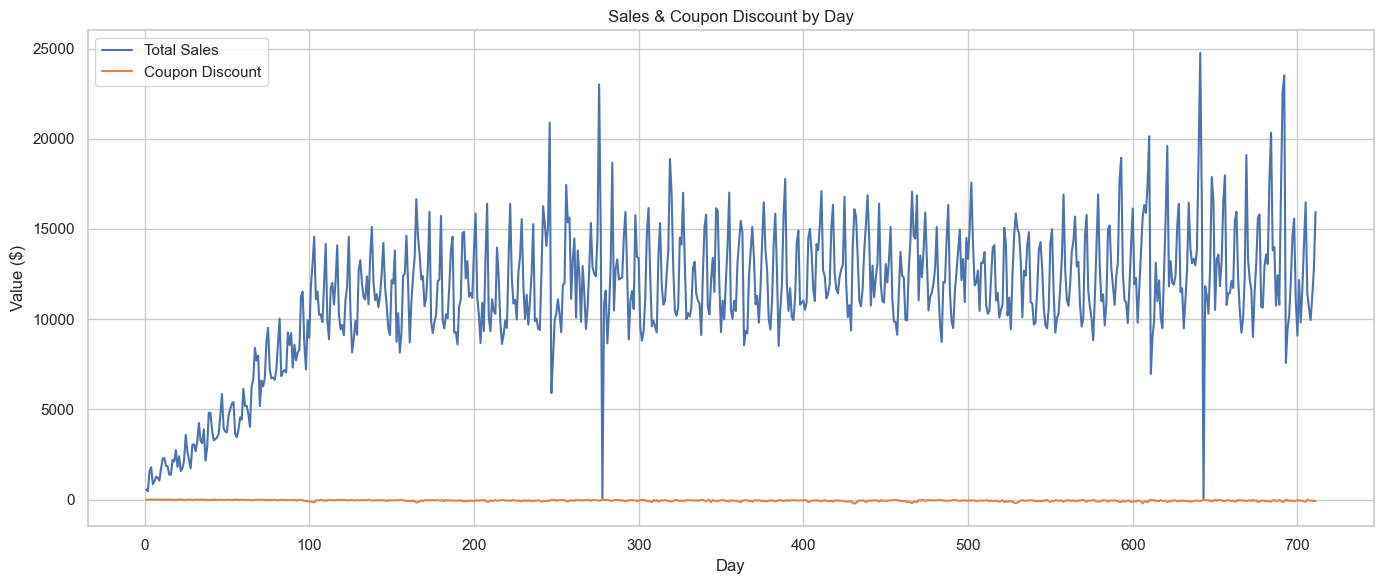

In [12]:
plt.figure(figsize=(14,6))
sns.lineplot(data=daily_metrics, x="DAY", y="total_sales", label="Total Sales")
sns.lineplot(data=daily_metrics, x="DAY", y="total_coupon_discount", label="Coupon Discount")
plt.title("Sales & Coupon Discount by Day")
plt.xlabel("Day")
plt.ylabel("Value ($)")
plt.legend()
plt.tight_layout()
plt.show()

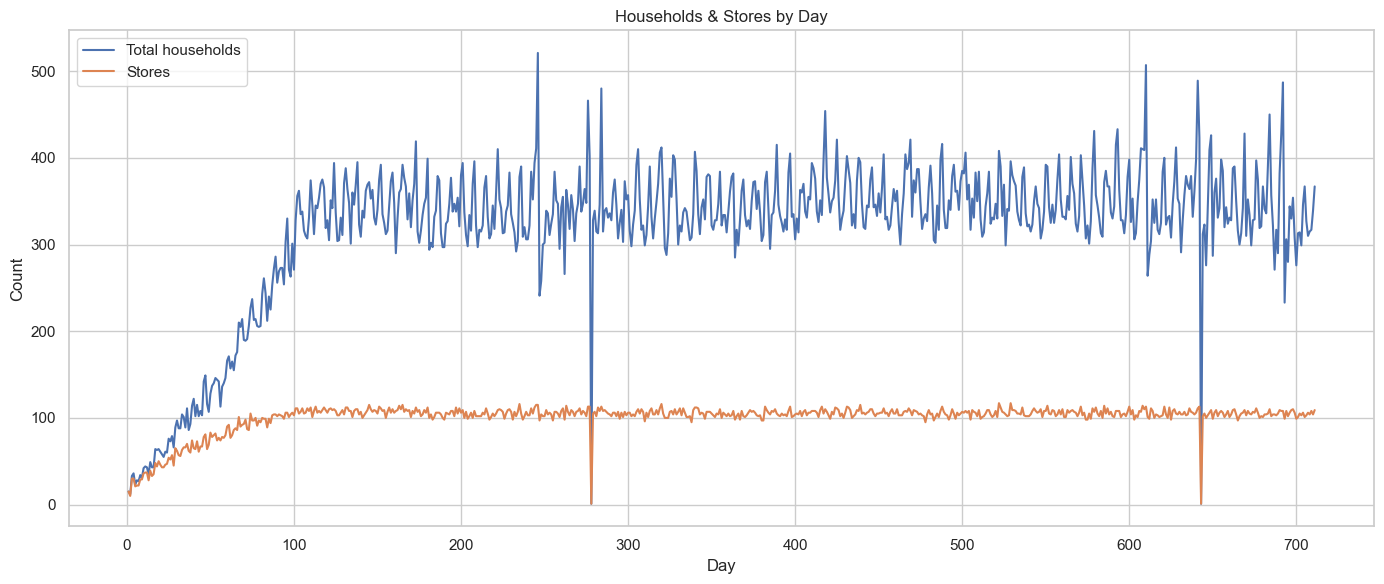

In [13]:
plt.figure(figsize=(14,6))
sns.lineplot(data=daily_metrics, x="DAY", y="distinct_households", label="Total households")
sns.lineplot(data=daily_metrics, x="DAY", y="distinct_stores", label="Stores")
plt.title("Households & Stores by Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

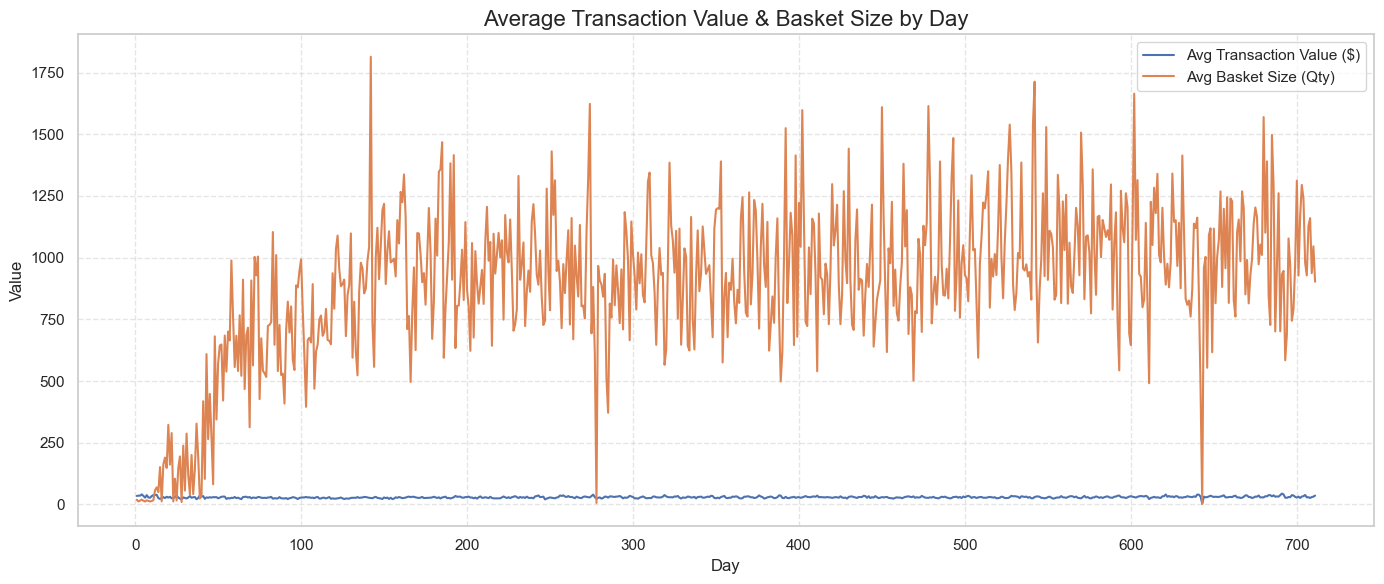

In [14]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_metrics, x="DAY", y="avg_transaction_value", label="Avg Transaction Value ($)")
sns.lineplot(data=daily_metrics, x="DAY", y="avg_basket_size", label="Avg Basket Size (Qty)")

plt.title("Average Transaction Value & Basket Size by Day", fontsize=16)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
transaction_aggregate = pd.DataFrame({
    'households': [transactions['household_key'].nunique()],
    'baskets': [transactions['BASKET_ID'].nunique()],
    'days': [transactions['DAY'].nunique()]
})
print(transaction_aggregate)


   households  baskets  days
0        2500   276484   711


In [18]:
transaction_aggregate2 = hh_demographics[['household_key']].drop_duplicates().sort_values('household_key').reset_index(drop=True)


In [19]:
transaction_aggregate2

,household_key
0,1
1,7
2,8
3,13
4,16
...,...
796,2494
797,2496
798,2497
799,2498
